In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df=pd.read_csv("smartcart_customers.csv")

Feature Engineering

In [53]:
df.head()



,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [54]:
##Age
df["Age"]=2026-df["Year_Birth"]


In [55]:
##Customer joining date

df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["customer_tenure_days"]=reference_date-df["Dt_Customer"]

In [56]:
df.isnull().sum()

ID                       0
Year_Birth               0
Education                0
Marital_Status           0
Income                  24
Kidhome                  0
Teenhome                 0
Dt_Customer              0
Recency                  0
MntWines                 0
MntFruits                0
MntMeatProducts          0
MntFishProducts          0
MntSweetProducts         0
MntGoldProds             0
NumDealsPurchases        0
NumWebPurchases          0
NumCatalogPurchases      0
NumStorePurchases        0
NumWebVisitsMonth        0
Complain                 0
Response                 0
Age                      0
customer_tenure_days     0
dtype: int64

In [57]:
##spendings

df["Total_spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [58]:
##children
df["total_children"]=df["Kidhome"]+df["Teenhome"]

In [59]:
##Education

##converting the education ststus into undergraduate postgraduate and graduate

df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate","phD":"Postgraduate"
})

In [60]:
##Marital Status
df["Living_with"]=df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})


In [61]:
df["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

In [62]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'Total_spending',
       'total_children', 'Living_with'],
      dtype='object')

Drop Unnecessary Columns

In [63]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop=cols+spending_cols
df_cleaned=df.drop(cols_to_drop,axis=1)

In [64]:
df_cleaned.shape

(2240, 15)

In [65]:
df.shape

(2240, 27)

In [66]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'Total_spending',
       'total_children', 'Living_with'],
      dtype='object')

Outlier detection

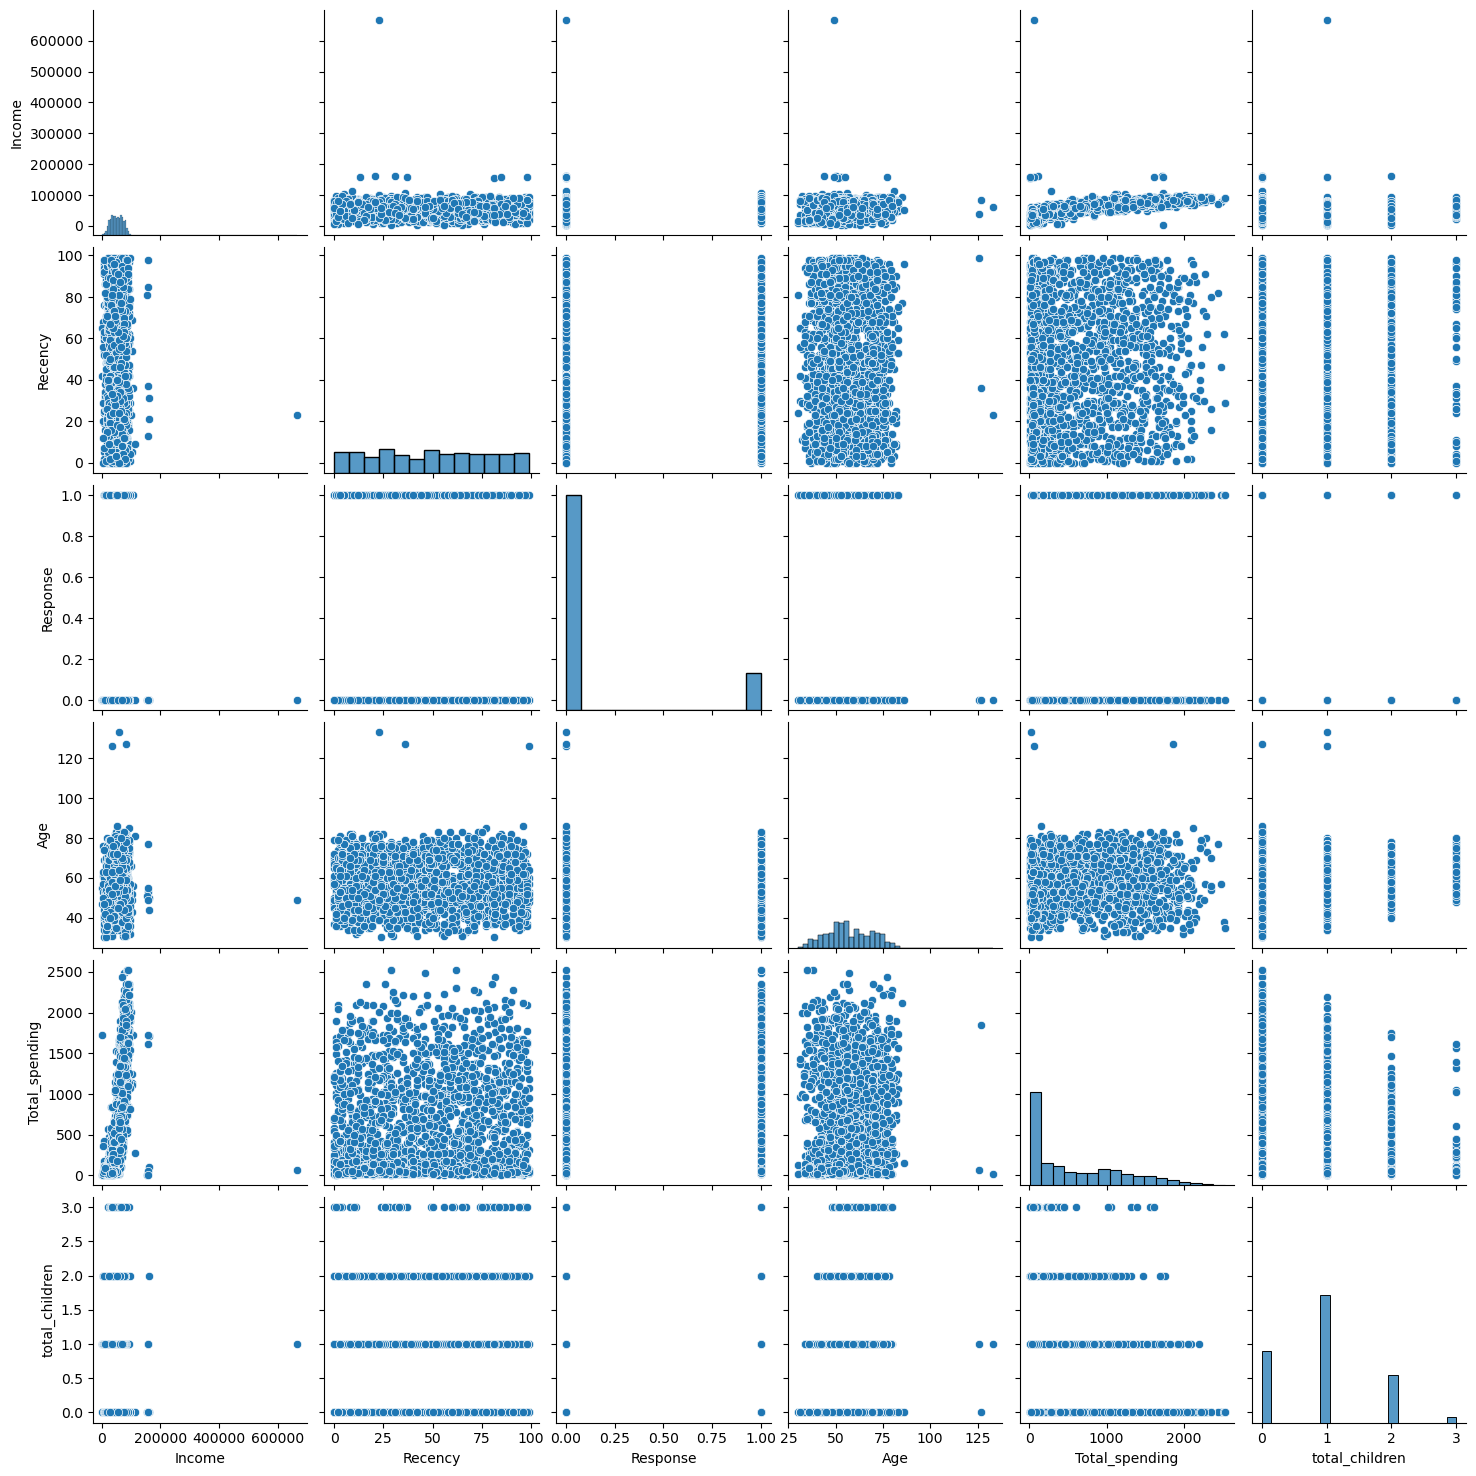

In [67]:
columns=["Income","Recency","Response","Age","Total_spending","total_children"]

##relative plots of features--pair plot

sns.pairplot(df_cleaned[columns])

In [68]:
##remove outliers

print("data size with outliers",len(df_cleaned))

df_cleaned=df_cleaned[df_cleaned["Age"]<90]
df_cleaned=df_cleaned[df_cleaned["Income"]<600_000]

print("data size without outliers",len(df_cleaned))

data size with outliers 2240
data size without outliers 2212


Heatmap

In [69]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

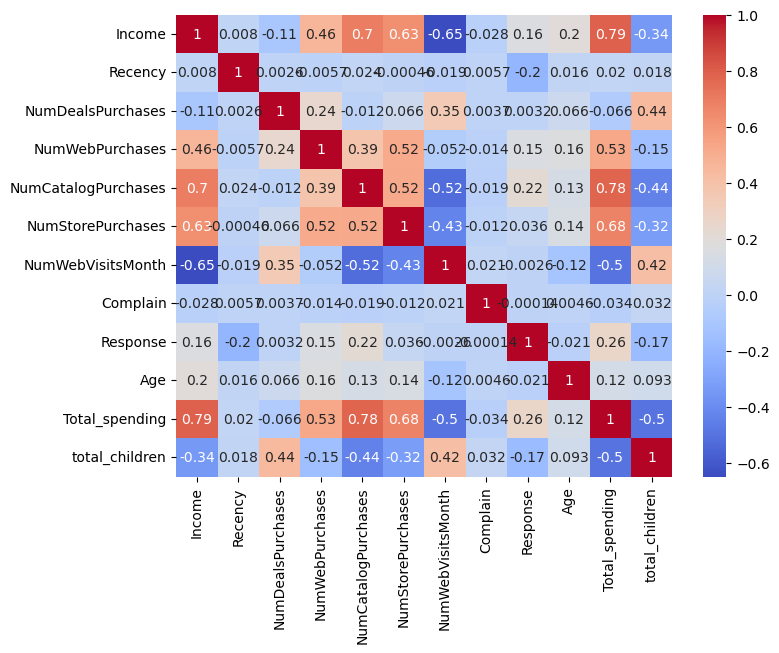

In [70]:
from seaborn import heatmap

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

In [71]:
df_cleaned.shape

(2212, 15)

Feature Encoding

In [72]:
from sklearn.preprocessing import OneHotEncoder

In [73]:
ohe=OneHotEncoder()
cat_cols=["Education","Living_with"]
ohe_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [74]:
enc_df=pd.DataFrame(ohe_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [75]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [76]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_spending,total_children,Education_Graduate,Education_PhD,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,1.0,0.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,1.0,0.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,1.0,0.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,1.0,0.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,0.0,1.0,0.0,0.0,0.0,1.0


Scaling

In [77]:
from sklearn.preprocessing import StandardScaler
x=df_encoded.select_dtypes(include=['int64','float64'])
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

Visualization

In [78]:
x_scaled.shape

(2212, 18)

In [79]:
##2d visualiztion

from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

array([0.23240555, 0.11385513])

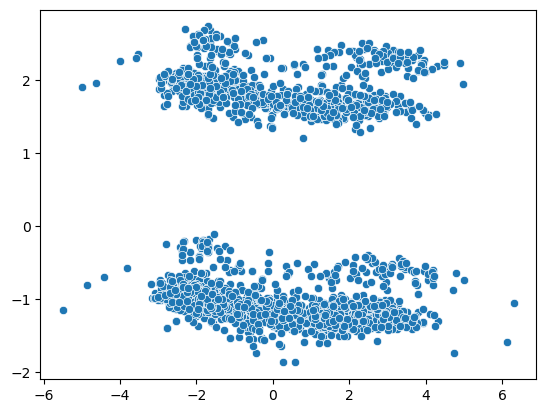

In [80]:
##plot

sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1])

pca.explained_variance_ratio_

In [81]:
pca=PCA(n_components=3)
x_pca=pca.fit_transform(x_scaled)

pca.explained_variance_ratio_

array([0.23240555, 0.11385513, 0.09535669])

In [82]:



fig=plt.Figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3d projection")

Text(0.5, 0.92, '3d projection')

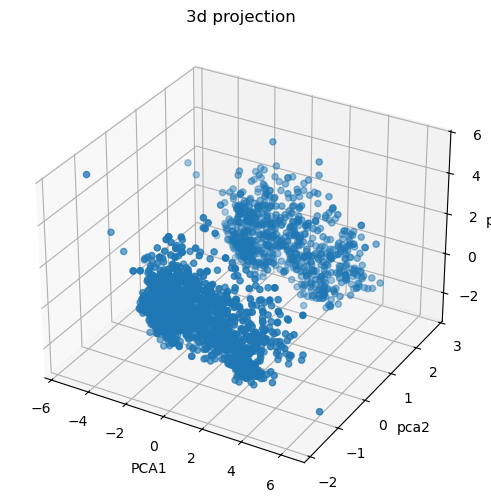

In [83]:
fig

Analayze k-value
1.Elbow Method

Text(0, 0.5, 'wcss')

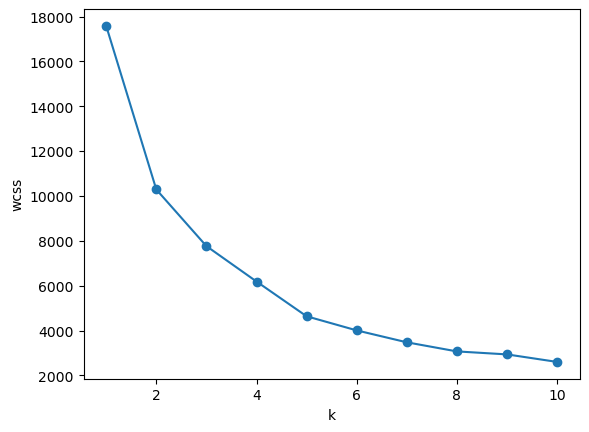

In [84]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]

for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

##plot

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("k")   
plt.ylabel("wcss")

In [85]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow

In [86]:
optimal_k

np.int64(3)

2.Silhoutte Score

Text(0, 0.5, 'silhoutte_score')

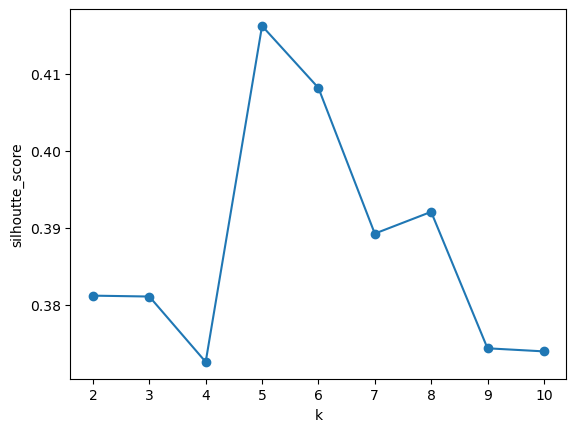

In [87]:
from sklearn.metrics import silhouette_score
scores=[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(x_pca)
    score=silhouette_score(x_pca,labels)
    scores.append(score)
    
##plot

plt.plot(range(2,11),scores,marker='o')
plt.xlabel("k")   
plt.ylabel("silhoutte_score")

Text(0, 0.5, 'silhoutte score')

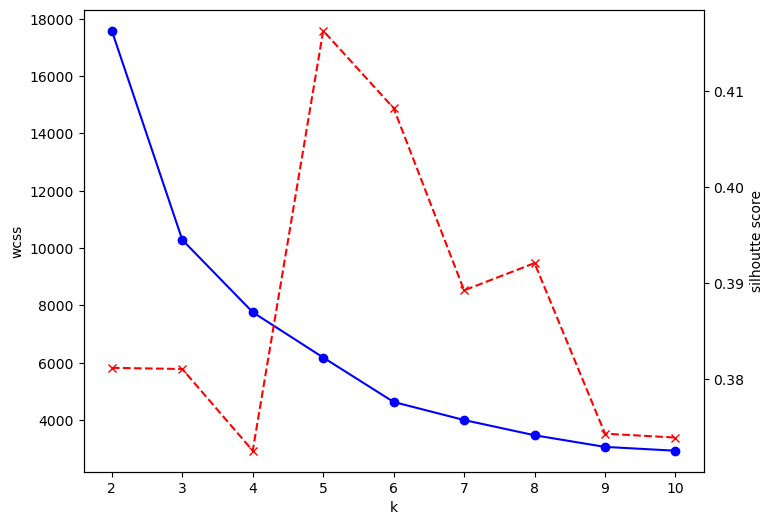

In [88]:
##combined plot

from turtle import color

from matplotlib.lines import lineStyles


k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))


ax1.plot(k_range,wcss[:len(k_range)],marker='o',color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker='x',color="red",linestyle="--")
ax2.set_ylabel("silhoutte score")

Clustering
1.K-Means

In [89]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(x_pca)

In [90]:
fig=plt.Figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_kmeans)
ax.set_xlabel("PCA1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3d projection")

Text(0.5, 0.92, '3d projection')

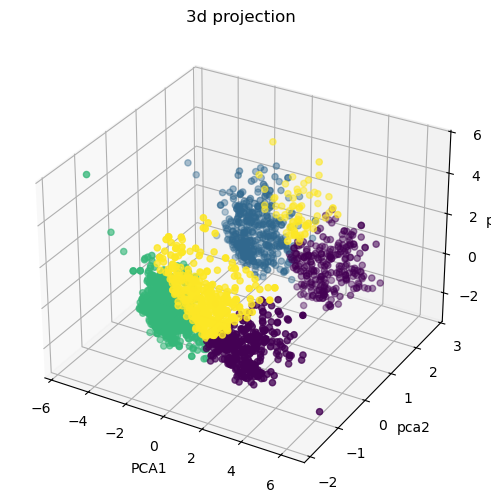

In [91]:
fig

2.Agglomerative Clustering

In [92]:
from sklearn.cluster import AgglomerativeClustering
agg_clr=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clr.fit_predict(x_pca)

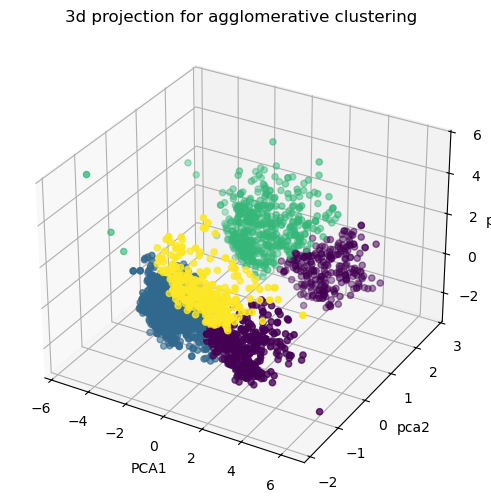

In [93]:
fig=plt.Figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_agg)
ax.set_xlabel("PCA1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3d projection for agglomerative clustering")
fig

Characterization of Clusters

In [94]:

x["clusters"]=labels_agg

<Axes: xlabel='clusters', ylabel='count'>

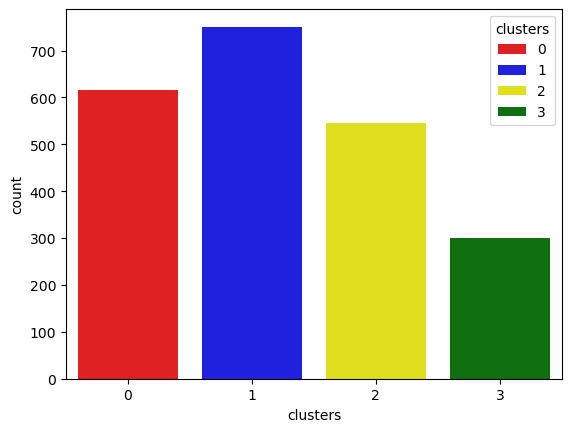

In [95]:
pal=["red","blue","yellow","green"]

sns.countplot(x=x["clusters"],palette=pal,hue=x["clusters"])

<Axes: xlabel='Total_spending', ylabel='Income'>

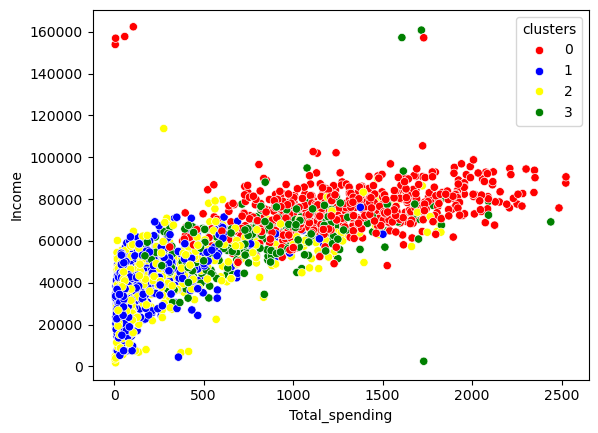

In [96]:
##income vs spending patterns

sns.scatterplot(x=x["Total_spending"],y=df_cleaned["Income"],hue=x["clusters"],palette=pal)

##cluster summary

In [98]:
cluster_summary=x.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         75442.858537  49.969106           1.276423         5.118699   
1         36951.601864  49.181092           2.158455         2.577896   
2         41790.212454  47.721612           2.719780         3.679487   
3         59891.406667  49.030000           4.170000         6.500000   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    5.671545           8.424390           2.840650  0.006504   
1                    0.752330           3.733688           6.278296  0.013316   
2                    1.434066           4.600733           6.492674  0.010989   
3                    3.583333           7.823333           5.880000  0.000000   

          Response        Age  Total_spending  total_children  \
clusters 